Transformation Notebook  
- at the end saved a new csv for cleaned data


In [42]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [43]:
big_nss = pd.read_csv("../data/big_nss.csv")
big_nss.head()

C:\Users\blond\AppData\Local\Temp\ipykernel_46732\3568697817.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  big_nss = pd.read_csv("../data/big_nss.csv")


,Unnamed: 0,RecordID,EventTimeStamp,EquipmentID,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd,Derate
0,0,1211417,2000-03-18 19:14:10,2015,25.52,190.85,274765.4,37866.421934,5673.1,False
1,1,1211418,2000-03-18 19:14:10,2015,25.52,190.85,274765.4,37866.421934,5673.1,False
2,2,1211419,2000-03-18 19:20:47,2015,NaN,NaN,NaN,NaN,NaN,False
3,3,1211420,2000-03-18 19:20:47,2015,NaN,NaN,NaN,NaN,NaN,False
4,4,1211422,2000-03-19 02:59:58,1849,NaN,NaN,NaN,NaN,NaN,False


Read in 'big_nss.csv' and save it as a dataframe named big_nss.  First, create a visualization to look at the 5 measurement columns to see how they compare when there is a derate vs not.  Ask Claude to help you write code that will compare 5 columns of numeric data for trucks experiencing a derate compared to those that aren't.

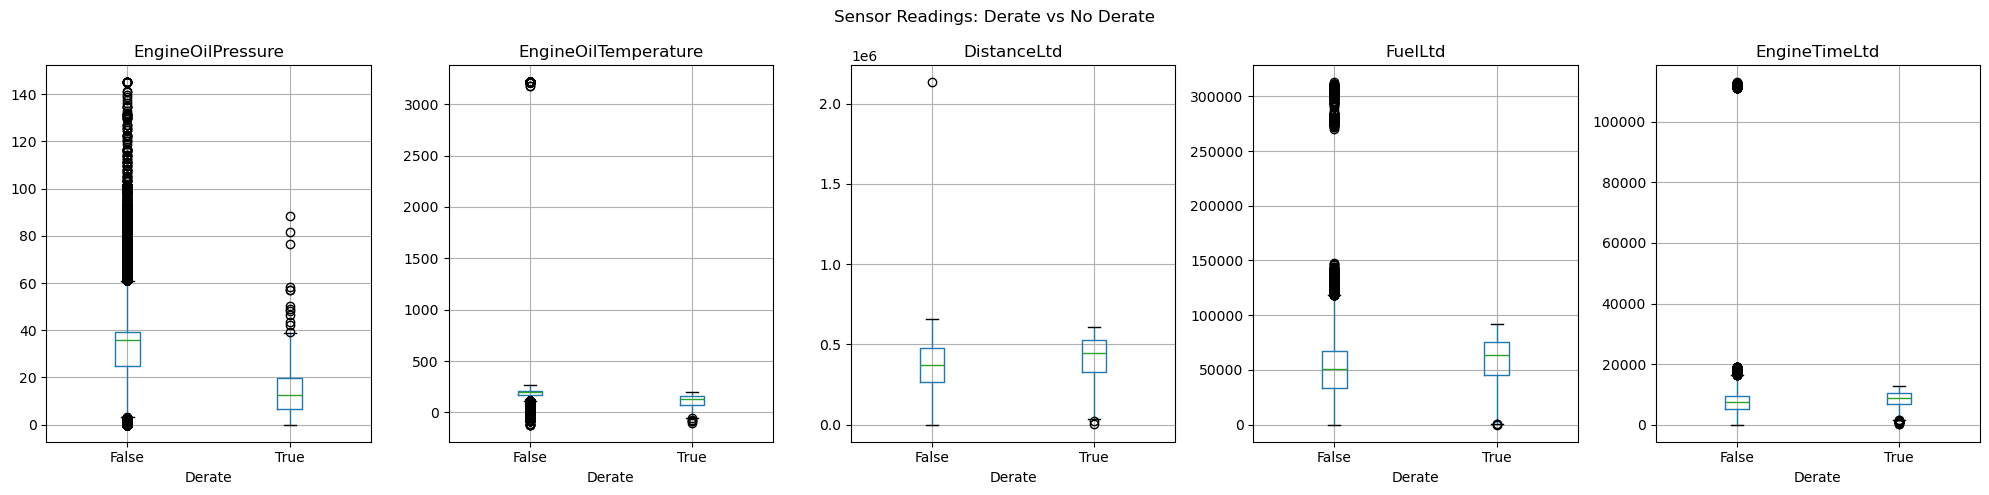

In [44]:
cols = ['EngineOilPressure', 'EngineOilTemperature', 'DistanceLtd', 'FuelLtd', 'EngineTimeLtd']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, cols):
    big_nss.boxplot(column=col, by='Derate', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Derate')

plt.suptitle('Sensor Readings: Derate vs No Derate')
plt.tight_layout()
plt.savefig("../images/og_data_plot.png", dpi=150, bbox_inches='tight')
plt.show()

Data imputation: 
  - Drop all rows that have null values for both "EngineOil" columns and all 3 "Ltd" columns  
  - Some trucks are completely missing values for one or more columns. Drop all EquipmentIDs that have only NaNs in at least 2 of the 'Ltd' columns (the entire column not by row)
  - Next for nulls in the 'Ltd' columns where there is at least 1 'Ltd' value, predict the others based on the existing 'Ltd' value.
  - Next for the remaining nulls in the Ltd columns, replace nulls by a value equally incremented from the last nonnull in that columns to the next nonnull for the same EquipmentID.
  - Next for the EngineOil columns we will want to do 1 of two possible methods of replacing nulls.  For rows where both EngineOil columns are
  missing predict the value based on the Ltd columns.  When only 1 of the EngineOil values is missing use the non-null EngineOil value with the
  Ltd columns to predict the value.

In [45]:
oil_cols = ['EngineOilPressure', 'EngineOilTemperature']
ltd_cols = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']

In [ ]:
# dropping rows where both engine oil columns are null, and all ltd columns are null, printing counts to know how many rows are being affected each transformation

rows_before = len(big_nss)
mask = big_nss[oil_cols].isna().all(axis=1) & big_nss[ltd_cols].isna().all(axis=1)
big_nss = big_nss[~mask]

print(f"Rows before: {rows_before}")
print(f"Rows after:  {len(big_nss)}")
print(f"Rows dropped: {rows_before - len(big_nss)}")

Rows before: 1187335
Rows after:  587635
Rows dropped: 599700


In [47]:
# dropping ids where there is only nans in at least 2 of the ltd columns

rows_before = len(big_nss)
all_null_per_equipment = big_nss.groupby('EquipmentID')[ltd_cols].apply(lambda g: g.isna().all())
bad_ids = all_null_per_equipment[all_null_per_equipment.sum(axis=1) >= 2].index
big_nss = big_nss[~big_nss['EquipmentID'].isin(bad_ids)]

print(f"Rows before:  {rows_before}")
print(f"Rows after:   {len(big_nss)}")
print(f"Rows dropped: {rows_before - len(big_nss)}")
print(f"\nEquipment IDs dropped ({len(bad_ids)}): {list(bad_ids)}")

Rows before:  587635
Rows after:   587630
Rows dropped: 5

Equipment IDs dropped (4): [105399896, 105406598, 105406673, 105531177]


In [48]:
# adding checking counts and data for rows changed to verify that filling worked and values made sense,

before_counts = big_nss[ltd_cols].isna().sum()
before_mask = big_nss[ltd_cols].isna().copy()

big_nss['EventTimeStamp'] = pd.to_datetime(big_nss['EventTimeStamp'])
big_nss = big_nss.sort_values(['EquipmentID', 'EventTimeStamp'])

for col in ltd_cols:
    null_mask = big_nss[col].isna()
    has_value = big_nss.groupby('EquipmentID')[col].transform('count') > 0
    target_mask = null_mask & has_value

    if not target_mask.any():
        continue

    big_nss['_ts'] = big_nss['EventTimeStamp'].where(big_nss[col].notna())
    fwd_ts = big_nss.groupby('EquipmentID')['_ts'].transform('ffill')
    bwd_ts = big_nss.groupby('EquipmentID')['_ts'].transform('bfill')
    fwd_val = big_nss.groupby('EquipmentID')[col].transform('ffill')
    bwd_val = big_nss.groupby('EquipmentID')[col].transform('bfill')
    big_nss.drop(columns=['_ts'], inplace=True)

    fwd_dist = (big_nss['EventTimeStamp'] - fwd_ts).abs()
    bwd_dist = (bwd_ts - big_nss['EventTimeStamp']).abs()

    use_fwd = fwd_val.notna() & (bwd_val.isna() | (fwd_dist <= bwd_dist))
    filled = fwd_val.where(use_fwd, bwd_val)

    big_nss.loc[target_mask, col] = filled[target_mask]

features = ['DistanceLtd', 'FuelLtd']
target = 'EngineTimeLtd'
complete = big_nss[features + [target]].dropna()
model = LinearRegression().fit(complete[features], complete[target])
missing = big_nss[target].isna() & big_nss[features].notna().all(axis=1)
big_nss.loc[missing, target] = model.predict(big_nss.loc[missing, features])

after_counts = big_nss[ltd_cols].isna().sum()
filled_mask = before_mask & big_nss[ltd_cols].notna()
print("Nulls before:\n", before_counts)
print("\nNulls after:\n", after_counts)
print("\nRows filled per column:\n", before_counts - after_counts)
big_nss[filled_mask.any(axis=1)]

Nulls before:
 DistanceLtd      1811
FuelLtd          2437
EngineTimeLtd    6264
dtype: int64

Nulls after:
 DistanceLtd      0
FuelLtd          0
EngineTimeLtd    0
dtype: int64

Rows filled per column:
 DistanceLtd      1811
FuelLtd          2437
EngineTimeLtd    6264
dtype: int64


C:\Users\blond\AppData\Local\Temp\ipykernel_46732\816664823.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  big_nss[filled_mask.any(axis=1)]


,Unnamed: 0,RecordID,EventTimeStamp,EquipmentID,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd,Derate
1145003,1145003,1199920,2019-09-23 08:31:32,301,5.80,77.000,441403.50,61938.703914,10685.05,False
1145004,1145004,1199921,2019-09-23 08:31:32,301,5.80,77.000,441403.50,61938.703914,10685.05,False
1145005,1145005,1199922,2019-09-23 08:31:32,301,5.80,77.000,441403.50,61938.703914,10685.05,False
1145006,1145006,1199923,2019-09-23 08:31:32,301,5.80,77.000,441403.50,61938.703914,10685.05,False
1145007,1145007,1199924,2019-09-23 08:31:32,301,5.80,77.000,441403.50,61938.703914,10685.05,False
...,...,...,...,...,...,...,...,...,...,...
46929,46929,47490,2015-05-08 19:11:59,309,22.04,NaN,94225.05,13584.651516,1892.80,False
48464,48464,49030,2015-05-11 07:59:08,309,35.38,NaN,94236.29,13671.960379,1899.20,False
56861,56861,58381,2015-05-19 06:53:39,309,42.92,89.825,97819.91,14162.263708,1965.30,False
58169,58169,59688,2015-05-20 06:50:17,309,44.08,NaN,98385.84,14162.263708,1976.35,False


In [49]:
#  i think i worked to far ahead in the other cell (that was reworked a few times), but leaving this in case

# track nulls before interpolation
before_counts = big_nss[ltd_cols].isna().sum()
before_mask = big_nss[ltd_cols].isna().copy()

# interpolate within each EquipmentID group
big_nss[ltd_cols] = (
    big_nss.groupby('EquipmentID')[ltd_cols]
    .transform(lambda g: g.interpolate(method='linear', limit_direction='both'))
)

# how many were filled
after_counts = big_nss[ltd_cols].isna().sum()
print("Nulls before:\n", before_counts)
print("\nNulls after:\n", after_counts)
print("\nRows filled per column:\n", before_counts - after_counts)

# show rows that were filled
filled_mask = before_mask & big_nss[ltd_cols].notna()
big_nss[filled_mask.any(axis=1)]

Nulls before:
 DistanceLtd      0
FuelLtd          0
EngineTimeLtd    0
dtype: int64

Nulls after:
 DistanceLtd      0
FuelLtd          0
EngineTimeLtd    0
dtype: int64

Rows filled per column:
 DistanceLtd      0
FuelLtd          0
EngineTimeLtd    0
dtype: int64


,Unnamed: 0,RecordID,EventTimeStamp,EquipmentID,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd,Derate


In [50]:
before_counts = big_nss[oil_cols].isna().sum()
before_mask = big_nss[oil_cols].isna().copy()

complete = big_nss[oil_cols + ltd_cols].dropna()
both_missing = big_nss[oil_cols].isna().all(axis=1)

for target in oil_cols:
    other_oil = [c for c in oil_cols if c != target]

    if both_missing.any():
        m = LinearRegression().fit(complete[ltd_cols], complete[target])
        big_nss.loc[both_missing, target] = m.predict(big_nss.loc[both_missing, ltd_cols])

    one_missing = big_nss[target].isna() & big_nss[other_oil[0]].notna()
    if one_missing.any():
        features = other_oil + ltd_cols
        m = LinearRegression().fit(complete[features], complete[target])
        big_nss.loc[one_missing, target] = m.predict(big_nss.loc[one_missing, features])

after_counts = big_nss[oil_cols].isna().sum()
filled_mask = before_mask & big_nss[oil_cols].notna()
print("Nulls before:\n", before_counts)
print("\nNulls after:\n", after_counts)
print("\nRows filled per column:\n", before_counts - after_counts)
big_nss[filled_mask.any(axis=1)]

Nulls before:
 EngineOilPressure       1391
EngineOilTemperature    3723
dtype: int64

Nulls after:
 EngineOilPressure       0
EngineOilTemperature    0
dtype: int64

Rows filled per column:
 EngineOilPressure       1391
EngineOilTemperature    3723
dtype: int64


,Unnamed: 0,RecordID,EventTimeStamp,EquipmentID,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd,Derate
260191,260191,263481,2015-11-02 12:07:04,301,1.160000,185.713773,168945.70,23603.112416,3399.95,False
353896,353896,359933,2016-01-26 11:44:37,301,29.580000,184.274207,190452.50,26654.431703,3877.75,False
594821,594821,608807,2016-10-13 01:10:29,301,1.740000,184.884896,250634.20,34763.853269,5257.80,False
930685,930685,958841,2018-02-01 14:57:06,301,29.000000,182.535682,342642.20,47432.620281,7688.15,False
930686,930686,958842,2018-02-01 14:57:06,301,29.000000,182.535682,342642.20,47432.620281,7688.15,False
...,...,...,...,...,...,...,...,...,...,...
39784,39784,40357,2015-05-01 13:19:49,309,32.827882,184.962337,91162.27,13215.206901,1831.35,False
46929,46929,47490,2015-05-08 19:11:59,309,22.040000,185.407126,94225.05,13584.651516,1892.80,False
48464,48464,49030,2015-05-11 07:59:08,309,35.380000,184.825920,94236.29,13671.960379,1899.20,False
58169,58169,59688,2015-05-20 06:50:17,309,44.080000,184.405856,98385.84,14162.263708,1976.35,False


In [51]:
big_nss.to_csv("../data/big_nss_clean.csv", index=False)